# LAB 1

In [174]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

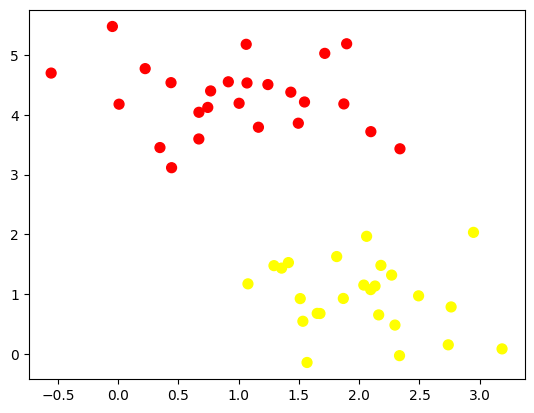

In [175]:
# Buat data dummy
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

(-1.0, 3.5)

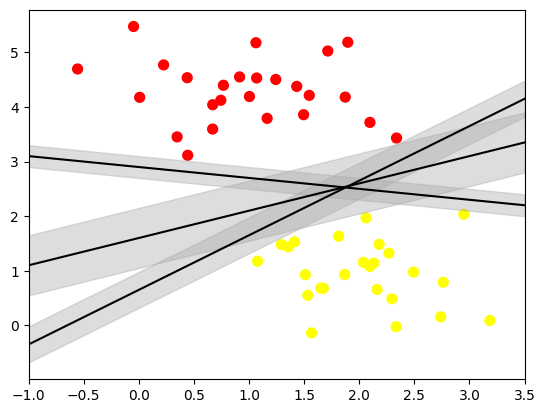

In [176]:
# Ilustrasi margin
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5)

In [177]:
# Fitting Model

from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

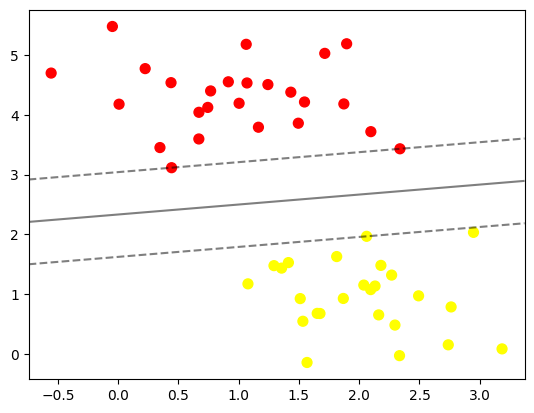

In [178]:
# Melakukan plotting dengan function yang telah di buat
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)

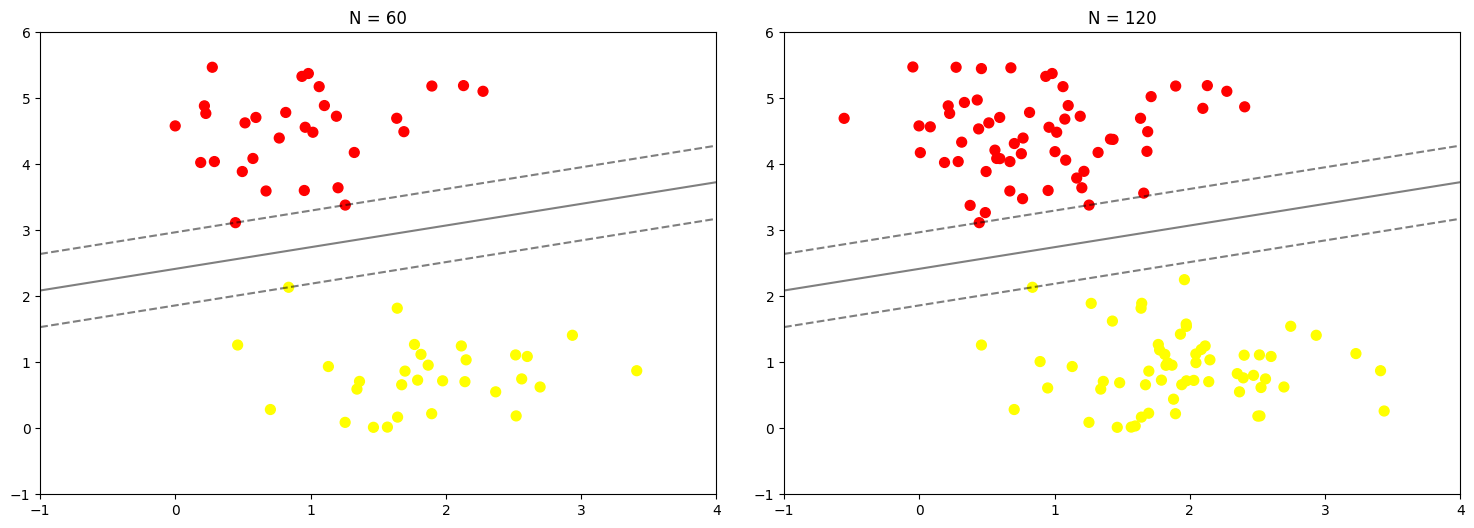

In [179]:
# Perbandingan
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

In [180]:
!pip install ipywidgets

In [181]:
# Perbandingan jika jumlah data banyak
# jumlah data dapat dipilih di antara 10 atau 200 buah data, telihat tidak ada perubahan pada model

from ipywidgets import interact, fixed
interact(plot_svm, N=[10, 200], ax=fixed(None))

interactive(children=(Dropdown(description='N', options=(10, 200), value=10), Output()), _dom_classes=('widget…

<function __main__.plot_svm(N=10, ax=None)>

# LAB 2

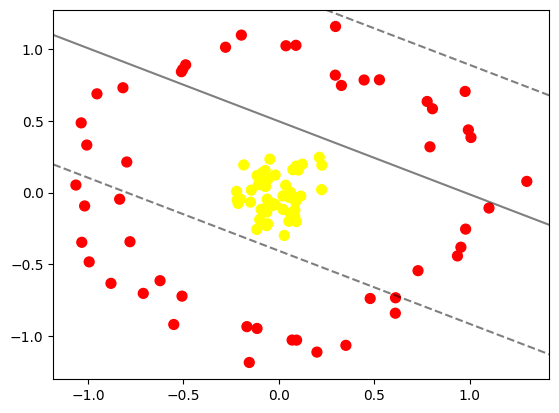

In [182]:
# Ilustrasi Data Non-Linier

# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

# Buat Kembali Fungsi Plotting
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Buat Data Dummy Non-Linier
    # contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [183]:
# Proyeksi radial

# Define radial func
r = np.exp(-(X**2).sum(1))

from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 0.29685031,  1.1589349 ],
       [-0.221832  ,  0.00807597],
       [ 0.72914014, -0.5451834 ],
       [-0.79724521,  0.21321043],
       [-0.51090107,  0.84342949],
       [ 0.02840316, -0.2993557 ],
       [-0.48861352,  0.89130151],
       [ 0.0830331 , -0.16571397],
       [-0.03492052, -0.09039839],
       [-0.62284433, -0.61501346],
       [ 0.93575788, -0.44222167],
       [-0.10662262,  0.0572459 ],
       [-0.04724357,  0.23330283],
       [ 1.2991589 ,  0.07787365],
       [ 0.80478228,  0.58491742],
       [ 0.1144155 , -0.02412759],
       [ 0.03690577,  1.02437334],
       [ 0.05985593,  0.00164417],
       [-0.14904608, -0.0672486 ],
       [-0.18454934,  0.19250012],
       [ 0.35104983, -1.06617801],
       [ 0.32770836,  0.74740326],
       [-0.16771267, -0.9357302 ],
       [-0.55088052, -0.92063581],
       [-0.78043908, -0.34312937],
       [ 0.0543276 , -0.03340595],
       [-0.10043112,  0.10749311],
       [ 0.22389848,  0.02031467],
       [ 0.47839906, -0.73939097],
       [-0.01947766,  0.12237715],
       [ 0.08755329, -0.06388679],
       [-0.09310201, -0.11806731],
       [ 0.05220908, -0.20032982],
       [-0.15521817, -1.18578637],
       [-0.01849145, -0.08447087],
       [-0.06452932, -0.23119838],
       [-1.01809054, -0.09346781],
       [-1.03305186, -0.34712529],
       [ 0.05898769, -0.14331987],
       [-0.21333038, -0.07589316],
       [-0.81726758,  0.7313462 ],
       [-0.05853486, -0.2185212 ],
       [-1.03609704,  0.48621347],
       [-0.11586986, -0.25697331],
       [-0.83448471, -0.04635085],
       [ 0.10188036,  0.1571721 ],
       [-0.27964895,  1.01413738],
       [-0.06364487, -0.13570515],
       [ 0.99282216,  0.43726045],
       [ 0.1992803 , -1.11334328],
       [-0.06117382, -0.04604836],
       [-1.00683791,  0.33158761],
       [ 0.06926836, -1.02927197],
       [ 0.61121325, -0.73426559],
       [ 0.95372496, -0.3814358 ],
       [-0.99425744, -0.48385486],
       [ 0.97600292,  0.7056293 ],
       [-0.03111342, -0.07693148],
       [-0.0720049 ,  0.15345894],
       [-0.19669085,  1.09868203],
       [ 0.44649036,  0.78543604],
       [ 0.12252241,  0.19806779],
       [ 0.22505512,  0.19102149],
       [-0.71072014, -0.70366778],
       [-0.11415835,  0.11854056],
       [ 0.5269098 ,  0.78670698],
       [ 0.61016964, -0.84182558],
       [ 0.09114938, -0.20279369],
       [ 0.08918049,  1.02752002],
       [-0.50773961, -0.72283677],
       [ 1.10102476, -0.10809024],
       [-0.11452298, -0.94841315],
       [ 0.07345719, -0.03134409],
       [-0.95349853,  0.68882504],
       [ 0.09262618, -1.02993922],
       [ 0.02126571, -0.02344354],
       [-0.05823522, -0.08945552],
       [ 0.07286069,  0.15961823],
       [-0.14476924,  0.01725321],
       [-0.08662053,  0.13831642],
       [ 0.03530135,  0.05106817],
       [-0.05800901,  0.09357363],
       [-1.06385446,  0.05241229],
       [ 0.02150029, -0.11777609],
       [-0.50382306,  0.86021346],
       [-0.21858866, -0.05088347],
       [-0.20107612, -0.04577741],
       [ 0.21172663,  0.24626755],
       [ 0.79160606,  0.31912317],
       [ 0.29556877,  0.8190943 ],
       [-0.10088421, -0.1879738 ],
       [-0.07843565,  0.04772938],
       [-0.06976561,  0.04213395],
       [ 0.08388938, -0.12193297],
       [ 1.00654213,  0.38429918],
       [ 0.09058125,  0.18447452],
       [ 0.77693792,  0.63548334],
       [ 0.97859097, -0.25509671],
       [-0.88002048, -0.63364089],
       [ 0.06152129, -0.00580111]]), y=array([0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1]))>

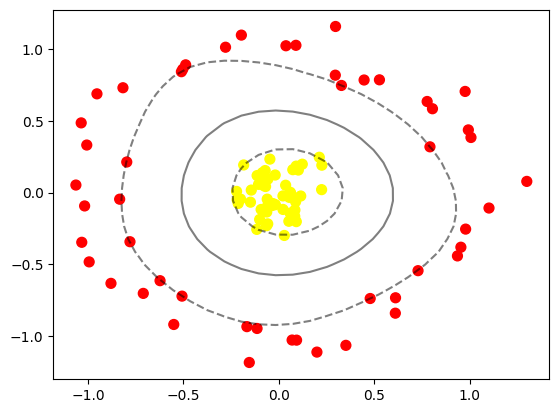

In [184]:
# Fitting Model
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

# Decision boundaries dari kernel RBF
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')

# LAB 3

In [185]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

# Buat Fungsi Plotting
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)



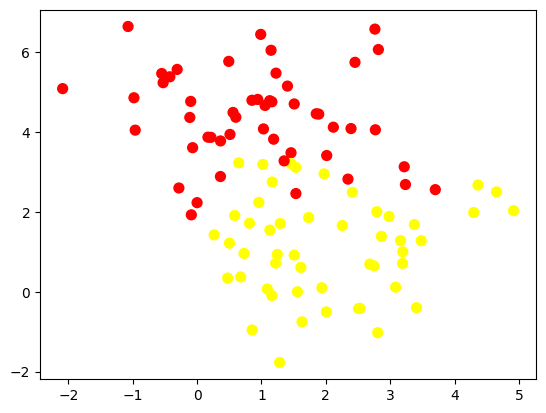

In [186]:
# Buat Data Dummy
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

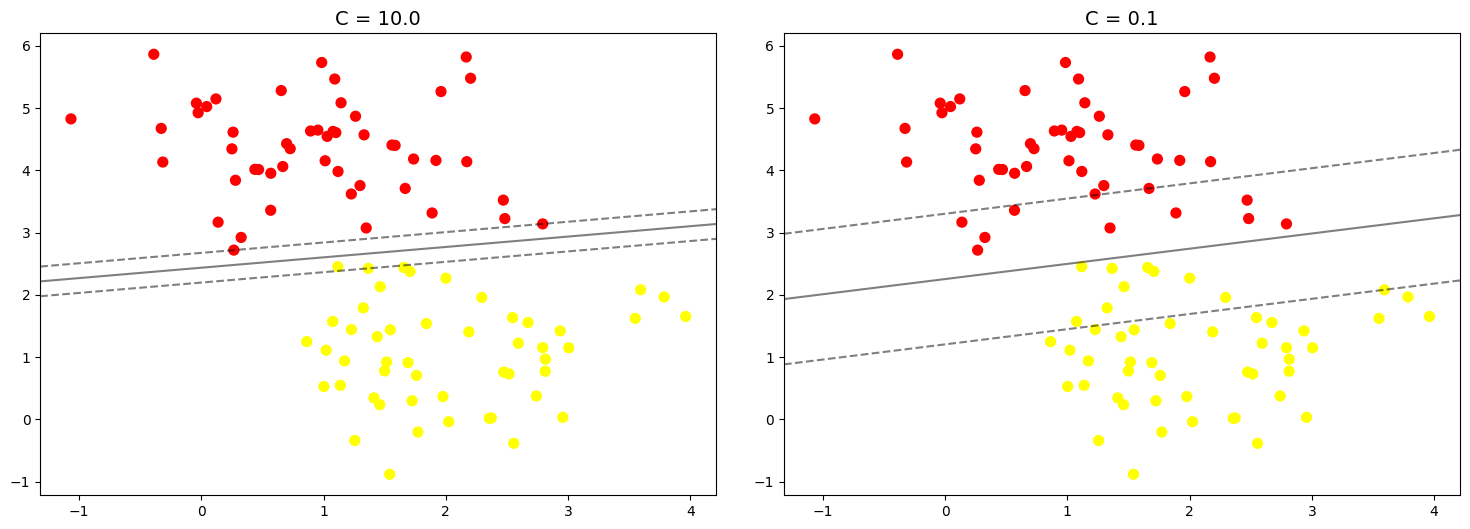

In [187]:
# Analisis Dampak Tunning
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

# LAB 4


In [188]:
# Unduh Dataset
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(len(faces.target_names))
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
8
(1348, 62, 47)


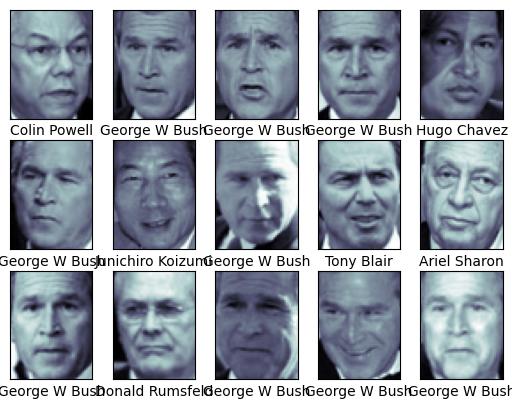

In [189]:
# Inspeksi Citra Wajah

# contoh wajah yang digunakan
from matplotlib import pyplot as plt

fig, ax = plt.subplots(3, 5)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

In [190]:
# Pra Pengolahan Data/Preprocessing data
from sklearn.svm import SVC
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.pipeline import make_pipeline

pca = RandomizedPCA(n_components=150, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')

# Pipeline digunakan untuk melakukan proses secara bertahap dalam
# 1 eksekusi fungsi secara langsung
model = make_pipeline(pca, svc)

In [191]:
# Split Data

# pemisahan data training dan data testing

from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target, random_state=42)


In [192]:
# Pembuatan Model + Tunning

from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)
print(grid.best_score_)

CPU times: user 2min 24s, sys: 202 ms, total: 2min 24s
Wall time: 1min 53s
{'svc__C': 5, 'svc__gamma': 0.001}
0.828893332683022


In [193]:
# Gunakan model terbaik tersebut untuk proses prediksi.
model = grid.best_estimator_
yfit = model.predict(Xtest)

Text(0.5, 0.98, 'Predicted Names; Incorrect Labels in Red')

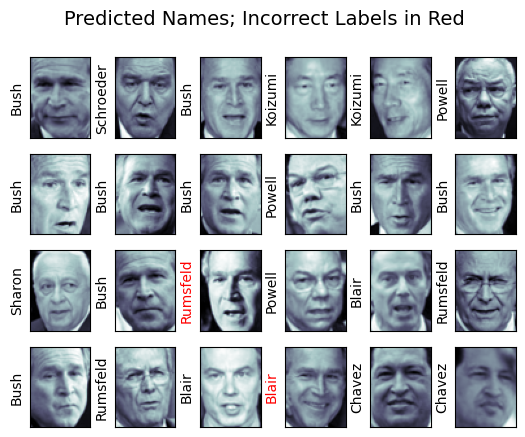

In [194]:
# Cek Hasil Prediksi
# hasil label pada data testing

fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14)

In [195]:
# Cek Performansi
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))



                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



Text(113.92222222222219, 0.5, 'predicted label')

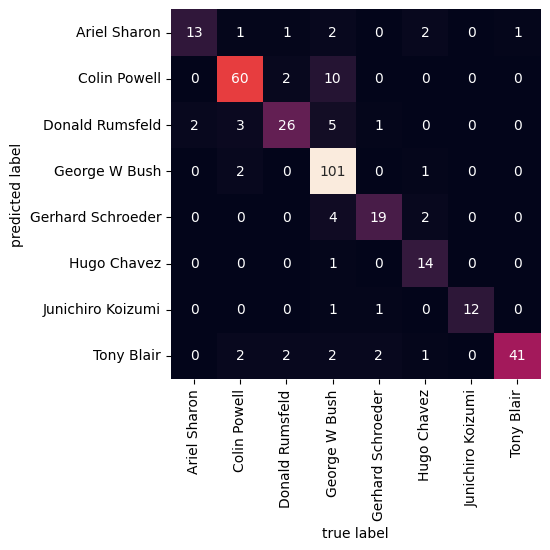

In [196]:
# Confusion matrix untuk mengetahui label label yang terklasifikasi  dengan benar dan tidak.
# bentuk confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')

# LAB 5

In [197]:
# Import Required Libraries
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

In [198]:
# Image directories
train_dir = "/content/drive/MyDrive/images/training"
test_dir = "/content/drive/MyDrive/images/test"

In [199]:
# Load data dan visualisasi
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = str(dir).split('/')[-1]
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))

    return img_list

In [200]:
# Load gambar training

# Load training data
train_img = load_dataset(train_dir)

In [201]:
# Check the first data
# It should be a tuple consist of arrays of image and image labels
train_img[0]

(array([[[ 4,  4,  4],
         [ 4,  4,  4],
         [ 4,  4,  4],
         ...,
         [ 2,  2,  2],
         [ 2,  2,  2],
         [ 2,  2,  2]],
 
        [[ 3,  3,  3],
         [ 3,  3,  3],
         [ 3,  3,  3],
         ...,
         [ 2,  2,  2],
         [ 2,  2,  2],
         [ 2,  2,  2]],
 
        [[ 2,  2,  2],
         [ 2,  2,  2],
         [ 2,  2,  2],
         ...,
         [ 2,  2,  2],
         [ 2,  2,  2],
         [ 2,  2,  2]],
 
        ...,
 
        [[48, 80, 75],
         [40, 72, 67],
         [39, 70, 65],
         ...,
         [ 7,  1,  1],
         [ 7,  1,  1],
         [ 7,  1,  1]],
 
        [[45, 77, 72],
         [37, 69, 64],
         [37, 68, 63],
         ...,
         [ 9,  3,  3],
         [ 8,  2,  2],
         [ 8,  2,  2]],
 
        [[42, 74, 69],
         [34, 66, 61],
         [33, 64, 59],
         ...,
         [10,  4,  4],
         [ 9,  3,  3],
         [ 9,  3,  3]]], dtype=uint8),
 'night')

In [202]:
# Random size checking
pick_random = np.random.randint(0, len(train_img))

# Check img size
print(f'Image {pick_random}')
print(train_img[pick_random][0].shape)

Image 88
(372, 640, 3)


In [203]:
# Function to Visualize
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))

    img = img_list[rand_num][0]
    label = img_list[rand_num][1]
    label_str = 'day' if label == 1 else 'night'

    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

Shape	: (700, 1280, 3)
Label	: day


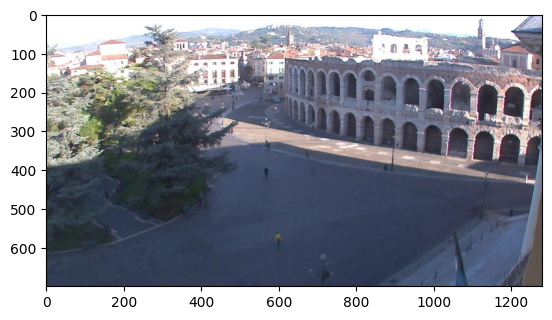

In [204]:
# Visualisasi gambar secara acak
random_img_viz(train_img)

In [205]:
# Pra Pengolahan Data / preprocessing data

# Standardisasi ukuran gambar
def standarized_input(image):
    # resize to w: 1100, h:600
    std_img = cv2.resize(image, (1100,600))

    return std_img

# Encoding label
def label_encoder(label):
    # Encode the label
    # day as 1; night as 0
    num_val = 0

    if(label == 'day'):
        num_val = 1

    return num_val

# Function untuk standarisasi dan encoding
def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        # Standarized the image
        std_img = standarized_input(image)

        # Create the label
        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))

    return std_img_list

In [206]:
# Preprocessing data training
train_std_img_list = preprocess(train_img)

In [207]:
# Random size checking
pick_random = np.random.randint(0, len(train_std_img_list))

# Check img size
print(f'Image {pick_random}')
print(train_std_img_list[pick_random][0].shape)

Image 214
(600, 1100, 3)


Shape	: (600, 1100, 3)
Label	: 0


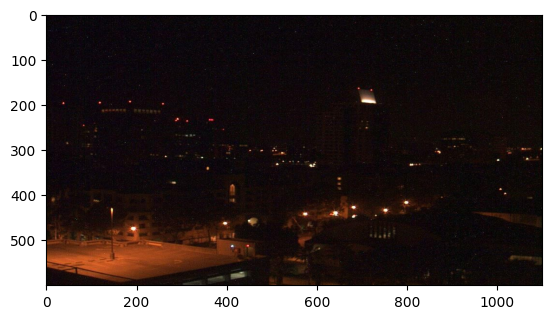

In [208]:
random_img_viz(train_std_img_list)

In [209]:
# Ekstraksi Fitur
# Get feature based on average brightness using HSV colorspace
def avg_brightness(image):
    # Convert image to HSV
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Calculate the avg of brightness
    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rb value which is the V channel
    area = image.shape[0] * image.shape[1]
    avg = sum_brightness / area

    return avg

Image 211
Avg Brighness: 143.3643


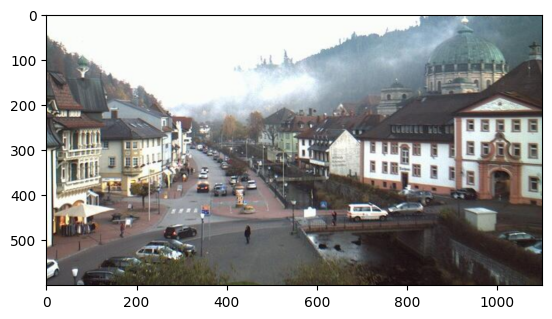

In [210]:
# Check on random image
rand_img = np.random.randint(0, len(train_std_img_list))

feature_img = train_std_img_list[rand_img][0]

avg_img = avg_brightness(feature_img)

print(f'Image {rand_img}')
print(f'Avg Brighness: {avg_img:.4f}')
plt.imshow(feature_img)

Image 211
Actual label: 1
Predicted label: 1


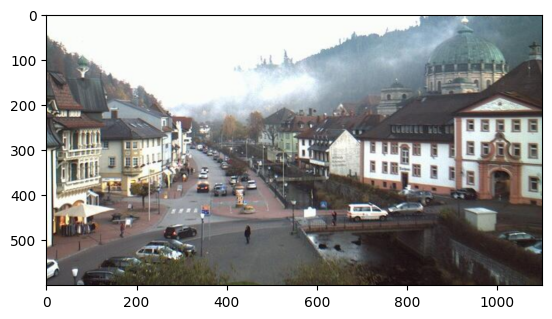

In [211]:
# Klasifikasi dengan Metode Threshold
def predict_label(img, threshold):
    # Computer average brightness
    avg = avg_brightness(img)
    pred = 0

    # Predict the label based on user defined threshold
    if avg > threshold:
        pred = 1

    return pred

# Test the classifier on train data
rand_img = np.random.randint(0, len(train_std_img_list))

pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

# Evaluate
print(f'Image {rand_img}')
print(f'Actual label: {train_std_img_list[rand_img][1]}')
print(f'Predicted label: {pred}')
plt.imshow(train_std_img_list[rand_img][0])

In [212]:
# Evaluasi Manual
# Confussion matrix
def evaluate(img_list, threshold):
    miss_labels = []

    for file in img_list:
        # Get the ground truth / correct label
        img = file[0]
        label = file[1]

        # Get prediction
        pred_label = predict_label(img, threshold)

        # Compare ground truth and pred
        if pred_label != label:
            miss_labels.append((img, pred_label, label))

    total_img = len(img_list)
    corr_pred = total_img - len(miss_labels)
    accuracy = corr_pred / total_img

    print(f'Accuracy: {accuracy:.4f}')

In [213]:
# Evaluasi data training
# Evaluate on train data
evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8423


In [214]:
# Evaluasi data test
# Evaluate on test data

# Load test data
test_img = load_dataset(test_dir)

# Preprocess
test_std_img_list = preprocess(test_img)

# Predict
evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


In [215]:
# Membuat Feature Vectors
# Create function to extract feature for every images and stored in tabular data
# Stored in Pandas dataframe
def extract_avg_bright_feature(img_list):
    avg_list = []
    labels = []

    for img in img_list:
        img_avg = avg_brightness(img[0]) # Get the avg brightness from image
        img_label = img[1] # Get the image label

        avg_list.append(img_avg)
        labels.append(img_label)

    # Stack data in columcular way
    data = np.column_stack((avg_list, labels))
    # Create a Pandas dataframe
    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

    return df

In [216]:
# Cek hasilnya pada data training
# Extract feature on train data
train_avg_img = extract_avg_bright_feature(train_std_img_list)
print(f'Shape: {train_avg_img.shape}')
train_avg_img.head()

# Testing
# Do the same thing on test data
test_avg_img = extract_avg_bright_feature(test_std_img_list)
print(f'Shape: {test_avg_img.shape}')
test_avg_img.head()

Shape: (241, 2)
Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,201.607444,1.0
1,194.228062,1.0
2,185.917073,1.0
3,191.237441,1.0
4,129.381088,1.0


In [217]:
# Buat Model SVM
# import requied library
from sklearn.svm import SVC

# Split data and label
X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
y_train = train_avg_img.iloc[:,1]
X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
y_test = test_avg_img.iloc[:,1]

model = SVC()
model.fit(X_train, y_train)

SVC()

In [218]:
# Evaluasi
from sklearn.metrics import accuracy_score

# Make a prediction on train data
y_train_pred = model.predict(X_train)

# Get the accuracy on train data
acc_train = accuracy_score(y_train, y_train_pred)

# Make a prediction on test data
y_test_pred = model.predict(X_test)

# Get the accuracy on test data
acc_test = accuracy_score(y_test, y_test_pred)

# Print Eval Result
print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8589211618257261
Accuracy on test: 0.9


Tugas LAB

In [219]:
# Model SVM dengan Dataset voice
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Load dataset
df = pd.read_csv('/content/drive/MyDrive/voice.csv')

# Separasi fitur (X) dan target (y)
X = df.drop(columns=['label'])
y = df['label']

# Standarisasi Fitur (Sangat direkomendasikan untuk SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Konfigurasi pengujian
ratios = [(0.30, '70:30'), (0.20, '80:20')]
kernels = ['linear', 'poly', 'rbf']

results = []

# Iterasi untuk setiap split dan kernel
for test_size, ratio_label in ratios:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    for kernel in kernels:
        model = SVC(kernel=kernel)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        results.append({
            'Split Data': ratio_label,
            'Kernel SVM': kernel,
            'Akurasi': f"{acc * 100:.2f}%"
        })

# Tabulasi Hasil
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))



Split Data Kernel SVM Akurasi
     70:30     linear  97.06%
     70:30       poly  95.69%
     70:30        rbf  98.11%
     80:20     linear  97.63%
     80:20       poly  96.85%
     80:20        rbf  98.26%


In [220]:
# Klasifikasi Siang dan Malam (Fitur Histogram Gambar)
import os
import cv2
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

def extract_histogram(image_path, bins=(8, 8, 8)):
    """Mengekstrak histogram HSV 3D dari gambar"""
    image = cv2.imread(image_path)
    if image is None:
        return None
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

def load_dataset_from_folder(base_folder):
    """Membaca gambar dari folder day dan night"""
    X, y = [], []
    categories = ['day', 'night']

    for category in categories:
        folder_path = os.path.join(base_folder, category)
        if not os.path.exists(folder_path):
            continue

        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            feat = extract_histogram(img_path)
            if feat is not None:
                X.append(feat)
                y.append(category)

    return np.array(X), np.array(y)

# 1. Tentukan path folder sesuai struktur yang Anda miliki
train_dir = '/content/drive/MyDrive/images/training'
test_dir = '/content/drive/MyDrive/images/test'

# 2. Load dataset training dan testing dari folder masing-masing
X_train, y_train = load_dataset_from_folder(train_dir)
X_test, y_test = load_dataset_from_folder(test_dir)

# Opsi Tambahan: Jika ingin menggabungkan seluruh data lalu split ulang 80:20
# (Sesuai instruksi "Gunakan rasio 80:20")
X_all = np.concatenate((X_train, X_test), axis=0)
y_all = np.concatenate((y_train, y_test), axis=0)

# 3. Standarisasi Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Split ulang dengan rasio 80:20 secara proporsional (stratify)
from sklearn.model_selection import train_test_split
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_scaled, y_all, test_size=0.20, random_state=42, stratify=y_all
)

# 4. Hyperparameter Tuning Kernel RBF menggunakan GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_split, y_train_split)

# 5. Evaluasi Performansi Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_split)
acc = accuracy_score(y_test_split, y_pred)

print(f"Hyperparameter Terbaik (RBF) : {grid_search.best_params_}")
print(f"Akurasi Pengujian             : {acc * 100:.2f}%\n")
print("Laporan Klasifikasi Detail:")
print(classification_report(y_test_split, y_pred))

Hyperparameter Terbaik (RBF) : {'C': 10, 'gamma': 0.001}
Akurasi Pengujian             : 98.77%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

         day       1.00      0.97      0.99        40
       night       0.98      1.00      0.99        41

    accuracy                           0.99        81
   macro avg       0.99      0.99      0.99        81
weighted avg       0.99      0.99      0.99        81

